# Training GPT on Shakespeare

Let's train our GPT model on the tinyshakespeare dataset. We'll use a small model configuration so it trains faster on CPU/MPS.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import tiktoken
from minigpt.model import GPTModel
from minigpt.data import create_dataloaders
from minigpt.generate import generate

## 1. Load Data

In [2]:
import urllib.request
import os

data_dir = '../data'
os.makedirs(data_dir, exist_ok=True)
filepath = os.path.join(data_dir, 'tinyshakespeare.txt')

if not os.path.exists(filepath):
    url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    urllib.request.urlretrieve(url, filepath)

with open(filepath, 'r') as f:
    text = f.read()

print(f'Dataset size: {len(text):,} characters')
print(f'First 200 chars:\n{text[:200]}')

Dataset size: 1,115,394 characters
First 200 chars:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


## 2. Model Config

We'll use a smaller model (4 layers, 4 heads, 128-dim embeddings) so it trains in reasonable time.

In [3]:
SMALL_CONFIG = {
    'vocab_size': 50257,
    'context_length': 256,
    'emb_dim': 128,
    'n_heads': 4,
    'n_layers': 4,
    'drop_rate': 0.0,
    'qkv_bias': False,
}

model = GPTModel(SMALL_CONFIG)
total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}')

Model parameters: 7,257,472


## 3. Create DataLoaders

In [4]:
tokenizer = tiktoken.get_encoding('gpt2')

train_loader, val_loader = create_dataloaders(
    text,
    tokenizer,
    max_length=SMALL_CONFIG['context_length'],
    stride=SMALL_CONFIG['context_length'],
    batch_size=8,
    train_ratio=0.9,
)

print(f'Training batches: {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')

Training batches: 148
Validation batches: 16


## 4. Training Loop

Simple training loop. Let's use a learning rate of 0.01 — should be fine for a small model.

In [5]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

NUM_EPOCHS = 5

Using device: mps


In [6]:
import math

train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    num_batches = 0

    for input_ids, target_ids in train_loader:
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)

        logits = model(input_ids)
        loss = torch.nn.functional.cross_entropy(
            logits.view(-1, logits.size(-1)),
            target_ids.view(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

        if num_batches % 50 == 0:
            print(f'  Epoch {epoch+1}, Batch {num_batches}, Loss: {loss.item():.4f}')

    avg_train_loss = epoch_loss / num_batches
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    val_batches = 0
    with torch.no_grad():
        for input_ids, target_ids in val_loader:
            input_ids = input_ids.to(device)
            target_ids = target_ids.to(device)
            logits = model(input_ids)
            loss = torch.nn.functional.cross_entropy(
                logits.view(-1, logits.size(-1)),
                target_ids.view(-1)
            )
            val_loss += loss.item()
            val_batches += 1

    avg_val_loss = val_loss / val_batches
    val_losses.append(avg_val_loss)

    print(f'Epoch {epoch+1}/{NUM_EPOCHS} — Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Perplexity: {math.exp(avg_val_loss):.1f}')
    print()

  Epoch 1, Batch 50, Loss: 7.9324
  Epoch 1, Batch 100, Loss: 6.4697
Epoch 1/5 — Train Loss: 10.1260, Val Loss: 6.4027, Perplexity: 603.5

  Epoch 2, Batch 50, Loss: 5.9592
  Epoch 2, Batch 100, Loss: 6.0912
Epoch 2/5 — Train Loss: 6.0136, Val Loss: 6.1286, Perplexity: 458.8

  Epoch 3, Batch 50, Loss: 5.5050
  Epoch 3, Batch 100, Loss: 5.7520
Epoch 3/5 — Train Loss: 5.6813, Val Loss: 5.8386, Perplexity: 343.3

  Epoch 4, Batch 50, Loss: 5.4558
  Epoch 4, Batch 100, Loss: 5.6353
Epoch 4/5 — Train Loss: 5.3509, Val Loss: 5.6984, Perplexity: 298.4

  Epoch 5, Batch 50, Loss: 5.2568
  Epoch 5, Batch 100, Loss: 5.2448
Epoch 5/5 — Train Loss: 5.0670, Val Loss: 5.4269, Perplexity: 227.4



## 5. Loss Curves

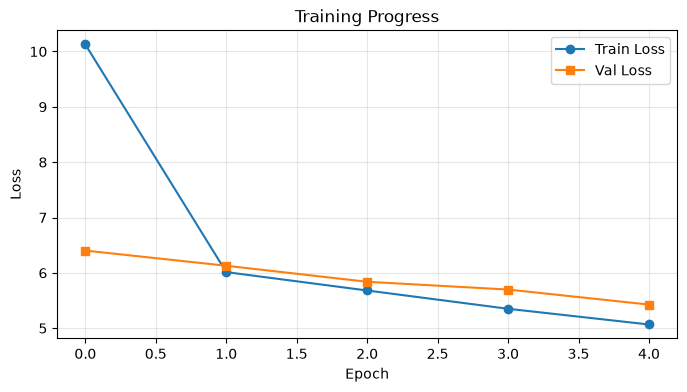

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Generate Text

In [8]:
model.eval()

prompt = 'To be or not to be'
input_ids = torch.tensor([tokenizer.encode(prompt)]).to(device)

with torch.no_grad():
    output_ids = generate(model, input_ids, max_new_tokens=100, context_length=SMALL_CONFIG['context_length'])

generated_text = tokenizer.decode(output_ids[0].tolist())
print(f'Prompt: {prompt}')
print(f'Generated:\n{generated_text}')

Prompt: To be or not to be
Generated:
To be or not to be,



And I am,









And I have you,


And I have you,





And,

And I am,
And I have you,

And I have have you,




And I'll be,
And I have you,


And I have you,
And I'll be
And,
And I have you,


